# Kapitel 6 – Intervallschätzung

**Mathematik III – Statistik, DHBW Stuttgart**

Dieses Notebook ist als **interaktive Lehrversion** zu Kapitel 6 gedacht.

Es enthält bewusst **keine Übungsaufgaben**, sondern erklärt ausführlich:

- die Idee von Konfidenzintervallen,
- die Rechnungen hinter den wichtigsten Formeln,
- die Interpretation der Grafiken,
- den Unterschied zwischen z-, t- und Chi-Quadrat-Intervallen,
- die Wirkung von Stichprobengröße, Streuung und Konfidenzniveau.

Die Beispiele orientieren sich an typischen IT-Kontexten wie API-Response-Zeiten, Server-Uptimes, Erfolgsquoten und CPU-Temperaturen.

## 0. Vorbereitung

Wir verwenden:

- `numpy` für numerische Rechnungen,
- `matplotlib` für Grafiken,
- `scipy.stats` für Quantile und Verteilungen.

Die Rechnungen sind bewusst transparent gehalten, damit man jeden Schritt nachvollziehen kann.

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

def de(x, digits=4):
    return f"{x:.{digits}f}".replace(".", ",")

print("Bibliotheken geladen.")

Bibliotheken geladen.


## 1. Warum Intervallschätzung?

In Kapitel 5 wurden **Punktschätzer** betrachtet.

Ein Punktschätzer liefert genau **einen Wert**, zum Beispiel:

\[
\bar{x} = 245 \text{ ms}
\]

für die mittlere Response-Zeit einer API.

Das Problem:

> Ein einzelner Schätzwert sagt noch nicht, wie unsicher diese Schätzung ist.

Bei einer Stichprobe von 100 Requests ist \(\bar{x}=245\) ms möglicherweise recht zuverlässig.  
Bei einer Stichprobe von nur 5 Requests wäre derselbe Wert deutlich unsicherer.

Die Intervallschätzung ergänzt daher den Punktschätzer um eine **Fehlertoleranz**:

\[
\text{Schätzwert} \pm \text{Fehlertoleranz}
\]

Typische Form:

\[
\bar{x} \pm \text{Quantil} \cdot \text{Standardfehler}
\]

## 2. Was bedeutet ein Konfidenzintervall?

Ein \((1-\alpha)\)-Konfidenzintervall ist ein zufälliges Intervall

\[
[U(X), O(X)]
\]

mit

\[
P(U(X) \le \theta \le O(X)) = 1-\alpha.
\]

Dabei ist wichtig:

- \(\theta\) ist der **feste, aber unbekannte Parameter**.
- \(U(X)\) und \(O(X)\) hängen von der Stichprobe ab.
- Vor der Stichprobenziehung ist das Intervall zufällig.
- Nach der Stichprobenziehung ist das konkrete Intervall fest.

### Häufige Fehlinterpretation

Falsch wäre:

> Der Parameter liegt mit 95 % Wahrscheinlichkeit in diesem konkreten Intervall.

Richtig ist:

> Wenn wir das Verfahren sehr oft wiederholen, enthalten etwa 95 % der so konstruierten Intervalle den wahren Parameter.

## 3. Simulation: Viele Konfidenzintervalle

Die folgende Simulation zeigt die eigentliche Bedeutung des Konfidenzniveaus.

Wir nehmen an:

- Der wahre Mittelwert sei \(\mu = 245\) ms.
- Die bekannte Standardabweichung sei \(\sigma = 30\) ms.
- Jede Stichprobe enthält \(n=25\) Messwerte.
- Für jede Stichprobe berechnen wir ein 95 %-Konfidenzintervall.

Einige Intervalle treffen den wahren Mittelwert, einzelne verfehlen ihn.

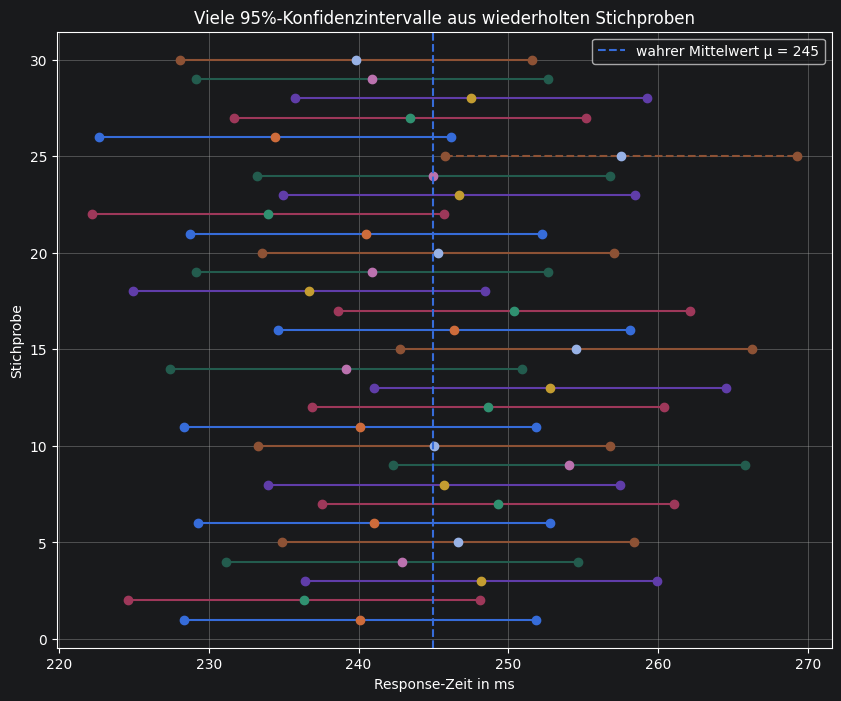

Anzahl Intervalle: 30
Überdecken den wahren Parameter: 29
Anteil: 0.967


In [34]:
np.random.seed(42)

mu_true = 245
sigma = 30
n = 25
anzahl_stichproben = 30
confidence = 0.95
alpha = 1 - confidence
z = stats.norm.ppf(1 - alpha/2)

means = []
lower_bounds = []
upper_bounds = []
covers = []

for _ in range(anzahl_stichproben):
    sample = np.random.normal(loc=mu_true, scale=sigma, size=n)
    x_bar = np.mean(sample)
    margin = z * sigma / np.sqrt(n)
    lower = x_bar - margin
    upper = x_bar + margin

    means.append(x_bar)
    lower_bounds.append(lower)
    upper_bounds.append(upper)
    covers.append(lower <= mu_true <= upper)

plt.figure(figsize=(10, 8))

for i, (lower, upper, x_bar, cover) in enumerate(zip(lower_bounds, upper_bounds, means, covers), start=1):
    if cover:
        plt.plot([lower, upper], [i, i], "o-")
    else:
        plt.plot([lower, upper], [i, i], "o--")
    plt.plot(x_bar, i, "o")

plt.axvline(mu_true, linestyle="--", label=f"wahrer Mittelwert μ = {mu_true}")
plt.xlabel("Response-Zeit in ms")
plt.ylabel("Stichprobe")
plt.title("Viele 95%-Konfidenzintervalle aus wiederholten Stichproben")
plt.legend()
plt.show()

print(f"Anzahl Intervalle: {anzahl_stichproben}")
print(f"Überdecken den wahren Parameter: {sum(covers)}")
print(f"Anteil: {sum(covers) / anzahl_stichproben:.3f}")

### Erklärung der Grafik

Jede horizontale Linie ist ein berechnetes Konfidenzintervall.

- Der Punkt auf der Linie ist der Stichprobenmittelwert \(\bar{x}\).
- Die vertikale gestrichelte Linie ist der wahre Mittelwert \(\mu\).
- Ein Intervall trifft \(\mu\), wenn es die vertikale Linie schneidet.
- Ein Intervall verfehlt \(\mu\), wenn es vollständig links oder rechts davon liegt.

Wichtig ist:

> Nicht jedes einzelne 95 %-Intervall muss den wahren Wert enthalten.  
> Aber langfristig treffen ungefähr 95 % der Intervalle.

Bei nur 30 Simulationen sieht man noch Zufallsschwankungen. Bei sehr vielen Wiederholungen nähert sich der Anteil dem Konfidenzniveau.

## 4. Konfidenzintervall für \(\mu\) bei bekannter Varianz

### Voraussetzungen

Wir betrachten den Fall:

\[
X_1,\dots,X_n \sim N(\mu,\sigma^2)
\]

mit bekannter Standardabweichung \(\sigma\).

Dann gilt für den Stichprobenmittelwert:

\[
\bar{X} \sim N\left(\mu,\frac{\sigma^2}{n}\right)
\]

Der Standardfehler des Mittelwerts ist:

\[
SE(\bar{X}) = \frac{\sigma}{\sqrt{n}}
\]

Das Konfidenzintervall lautet:

\[
\left[
\bar{x} - z_{1-\alpha/2}\frac{\sigma}{\sqrt{n}},
\quad
\bar{x} + z_{1-\alpha/2}\frac{\sigma}{\sqrt{n}}
\right]
\]

oder kürzer:

\[
\bar{x} \pm z_{1-\alpha/2}\frac{\sigma}{\sqrt{n}}.
\]

### Warum wird durch \(\sqrt{n}\) geteilt?

Der Mittelwert aus \(n\) unabhängigen Beobachtungen schwankt weniger als ein einzelner Messwert.

Für unabhängige Zufallsvariablen gilt:

\[
Var(\bar{X}) = Var\left(\frac{1}{n}\sum_{i=1}^n X_i\right)
\]

\[
= \frac{1}{n^2} \sum_{i=1}^n Var(X_i)
\]

Da alle \(X_i\) dieselbe Varianz \(\sigma^2\) haben:

\[
Var(\bar{X}) = \frac{1}{n^2} \cdot n\sigma^2
= \frac{\sigma^2}{n}
\]

Daraus folgt:

\[
SD(\bar{X}) = \frac{\sigma}{\sqrt{n}}
\]

Diese Größe heißt **Standardfehler**.

### Beispiel: API-Response-Zeit

Gegeben:

- \(n = 100\) API-Requests,
- \(\bar{x} = 245\) ms,
- \(\sigma = 30\) ms,
- Konfidenzniveau \(95\%\).

Für 95 % gilt:

\[
\alpha = 0{,}05,\qquad 1-\frac{\alpha}{2}=0{,}975
\]

Das benötigte Quantil ist:

\[
z_{0{,}975} \approx 1{,}96.
\]

In [35]:
x_bar = 245
sigma = 30
n = 100
confidence = 0.95

alpha = 1 - confidence
z = stats.norm.ppf(1 - alpha/2)

standard_error = sigma / np.sqrt(n)
margin = z * standard_error
lower = x_bar - margin
upper = x_bar + margin

print("Gegeben:")
print(f"x̄ = {x_bar} ms")
print(f"σ = {sigma} ms")
print(f"n = {n}")
print(f"Konfidenzniveau = {confidence:.0%}")
print()
print("Rechnung:")
print(f"α = {de(alpha, 2)}")
print(f"z_(1-α/2) = z_{de(1-alpha/2, 3)} = {de(z, 3)}")
print(f"Standardfehler = σ / √n = {sigma} / √{n} = {de(standard_error, 2)} ms")
print(f"Fehlertoleranz = z · Standardfehler = {de(z, 3)} · {de(standard_error, 2)} = {de(margin, 2)} ms")
print()
print("Konfidenzintervall:")
print(f"[{de(lower, 2)}, {de(upper, 2)}] ms")

Gegeben:
x̄ = 245 ms
σ = 30 ms
n = 100
Konfidenzniveau = 95%

Rechnung:
α = 0,05
z_(1-α/2) = z_0,975 = 1,960
Standardfehler = σ / √n = 30 / √100 = 3,00 ms
Fehlertoleranz = z · Standardfehler = 1,960 · 3,00 = 5,88 ms

Konfidenzintervall:
[239,12, 250,88] ms


### Erklärung der Rechnung

Die Rechnung besteht aus drei Schritten:

1. **Standardfehler berechnen**

\[
\frac{\sigma}{\sqrt{n}} = \frac{30}{\sqrt{100}} = 3
\]

Der Stichprobenmittelwert streut also nicht mit 30 ms, sondern nur mit 3 ms.

2. **Sicherheitsfaktor anwenden**

\[
1{,}96 \cdot 3 = 5{,}88
\]

Die Zahl 1,96 sorgt dafür, dass in der Standardnormalverteilung die mittleren 95 % abgedeckt werden.

3. **Intervall um den Mittelwert legen**

\[
245 \pm 5{,}88
\]

Also:

\[
[239{,}12,\;250{,}88]
\]

Das Intervall ist symmetrisch um \(\bar{x}=245\), weil die Normalverteilung symmetrisch ist.

## 5. Grafik: Standardnormalverteilung und z-Quantile

Die nächste Grafik zeigt, woher der Wert \(z_{0{,}975}=1{,}96\) kommt.

Für ein 95 %-Konfidenzintervall liegen 95 % der Fläche in der Mitte.  
Die restlichen 5 % liegen in den beiden Randbereichen:

\[
\frac{\alpha}{2}=0{,}025
\]

links und rechts.

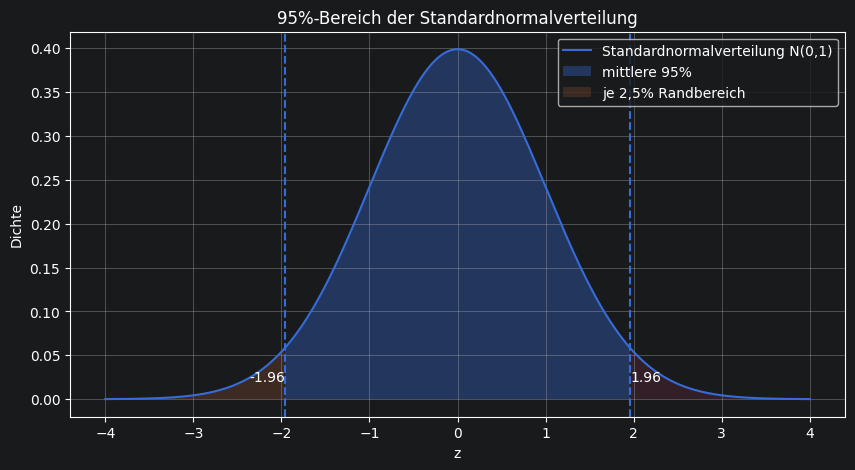

In [36]:
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)

alpha = 0.05
z = stats.norm.ppf(1 - alpha/2)

plt.figure(figsize=(10, 5))
plt.plot(x, y, label="Standardnormalverteilung N(0,1)")
plt.fill_between(x, y, where=(x >= -z) & (x <= z), alpha=0.35, label="mittlere 95%")
plt.fill_between(x, y, where=(x < -z), alpha=0.2, label="je 2,5% Randbereich")
plt.fill_between(x, y, where=(x > z), alpha=0.2)

plt.axvline(-z, linestyle="--")
plt.axvline(z, linestyle="--")
plt.text(-z, 0.02, f"-{z:.2f}", ha="right")
plt.text(z, 0.02, f"{z:.2f}", ha="left")

plt.title("95%-Bereich der Standardnormalverteilung")
plt.xlabel("z")
plt.ylabel("Dichte")
plt.legend()
plt.show()

### Erklärung der Grafik

Die Kurve zeigt die Dichte der Standardnormalverteilung.

Der mittlere Bereich zwischen

\[
-1{,}96 \quad \text{und} \quad +1{,}96
\]

enthält 95 % der Fläche.

Die beiden äußeren Bereiche enthalten zusammen 5 %:

- links 2,5 %,
- rechts 2,5 %.

Deshalb verwendet man beim zweiseitigen 95 %-Konfidenzintervall das Quantil

\[
z_{0{,}975}=1{,}96
\]

und nicht \(z_{0{,}95}\).

## 6. Einfluss von Stichprobengröße, Streuung und Konfidenzniveau

Die Breite des z-Intervalls wird bestimmt durch:

\[
E = z_{1-\alpha/2}\cdot \frac{\sigma}{\sqrt{n}}
\]

Dabei ist \(E\) die Fehlertoleranz.

### Wirkung der Größen

- Größeres \(n\) → kleinerer Standardfehler → engeres Intervall.
- Größeres \(\sigma\) → stärkere Streuung → breiteres Intervall.
- Höheres Konfidenzniveau → größeres Quantil → breiteres Intervall.

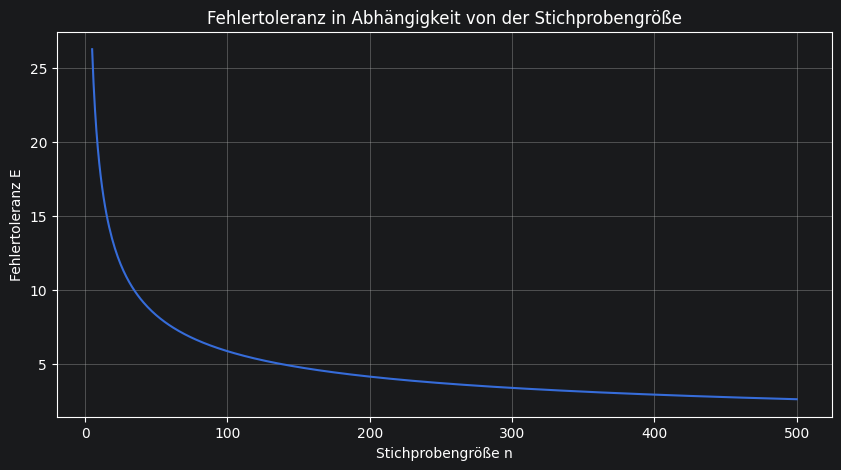

n= 10: Fehlertoleranz = 18,59 ms
n= 25: Fehlertoleranz = 11,76 ms
n= 50: Fehlertoleranz = 8,32 ms
n=100: Fehlertoleranz = 5,88 ms
n=400: Fehlertoleranz = 2,94 ms


In [37]:
sigma = 30
confidence = 0.95
alpha = 1 - confidence
z = stats.norm.ppf(1 - alpha/2)

n_values = np.arange(5, 501)
margins = z * sigma / np.sqrt(n_values)

plt.figure(figsize=(10, 5))
plt.plot(n_values, margins)
plt.title("Fehlertoleranz in Abhängigkeit von der Stichprobengröße")
plt.xlabel("Stichprobengröße n")
plt.ylabel("Fehlertoleranz E")
plt.show()

for n in [10, 25, 50, 100, 400]:
    margin = z * sigma / np.sqrt(n)
    print(f"n={n:3d}: Fehlertoleranz = {de(margin, 2)} ms")

### Erklärung der Grafik

Die Kurve fällt, aber nicht linear.

Wenn \(n\) vervierfacht wird, halbiert sich die Fehlertoleranz:

\[
\frac{1}{\sqrt{4n}} = \frac{1}{2\sqrt{n}}
\]

Das ist didaktisch wichtig:

> Doppelte Genauigkeit benötigt ungefähr viermal so viele Beobachtungen.

Beispiel:

- \(n=100\) ergibt eine Fehlertoleranz von ca. 5,88 ms.
- Für etwa 2,94 ms müsste man \(n\) ungefähr auf 400 erhöhen.

## 7. \(\mu\) bei unbekannter Varianz: t-Intervall

In der Praxis ist \(\sigma\) fast nie bekannt.

Dann wird \(\sigma\) durch die Stichprobenstandardabweichung \(s\) geschätzt.

Das Intervall lautet:

\[
\left[
\bar{x} - t_{n-1;1-\alpha/2}\frac{s}{\sqrt{n}},
\quad
\bar{x} + t_{n-1;1-\alpha/2}\frac{s}{\sqrt{n}}
\right]
\]

oder:

\[
\bar{x} \pm t_{n-1;1-\alpha/2}\frac{s}{\sqrt{n}}
\]

### Warum nicht einfach z?

Weil \(s\) selbst aus der Stichprobe geschätzt wird.

Dadurch entsteht zusätzliche Unsicherheit.  
Diese zusätzliche Unsicherheit wird durch die t-Verteilung berücksichtigt.

Die t-Verteilung ist:

- symmetrisch um 0,
- breiter als die Standardnormalverteilung,
- besonders bei kleinen Stichproben deutlich breiter,
- für große \(n\) fast identisch mit der Normalverteilung.

### Beispiel: Server-Uptime

Gegeben:

- \(n = 25\),
- \(\bar{x} = 720\) Stunden,
- \(s = 48\) Stunden,
- Konfidenzniveau 95 %.

Freiheitsgrade:

\[
df = n-1 = 24
\]

Quantil:

\[
t_{24;0{,}975} \approx 2{,}064
\]

In [38]:
x_bar = 720
s = 48
n = 25
confidence = 0.95

alpha = 1 - confidence
df = n - 1
t_quantile = stats.t.ppf(1 - alpha/2, df=df)

standard_error = s / np.sqrt(n)
margin = t_quantile * standard_error
lower = x_bar - margin
upper = x_bar + margin

print("Gegeben:")
print(f"x̄ = {x_bar} h")
print(f"s = {s} h")
print(f"n = {n}")
print(f"df = n - 1 = {df}")
print()
print("Rechnung:")
print(f"t_(df; 1-α/2) = t_({df}; {de(1-alpha/2, 3)}) = {de(t_quantile, 3)}")
print(f"Standardfehler = s / √n = {s} / √{n} = {de(standard_error, 2)} h")
print(f"Fehlertoleranz = {de(t_quantile, 3)} · {de(standard_error, 2)} = {de(margin, 2)} h")
print()
print("Konfidenzintervall:")
print(f"[{de(lower, 2)}, {de(upper, 2)}] h")

Gegeben:
x̄ = 720 h
s = 48 h
n = 25
df = n - 1 = 24

Rechnung:
t_(df; 1-α/2) = t_(24; 0,975) = 2,064
Standardfehler = s / √n = 48 / √25 = 9,60 h
Fehlertoleranz = 2,064 · 9,60 = 19,81 h

Konfidenzintervall:
[700,19, 739,81] h


### Erklärung der Rechnung

Der Ablauf ist fast identisch wie beim z-Intervall.

Der Unterschied liegt nur im Quantil:

- z-Intervall: \(z_{0{,}975}=1{,}96\)
- t-Intervall: \(t_{24;0{,}975}=2{,}064\)

Weil \(2{,}064 > 1{,}96\), wird das t-Intervall etwas breiter.

Das ist sinnvoll, weil \(s=48\) selbst nur geschätzt wurde.

## 8. Grafik: t-Verteilung im Vergleich zur Normalverteilung

Die nächste Grafik zeigt:

- die Standardnormalverteilung,
- eine t-Verteilung mit wenigen Freiheitsgraden,
- eine t-Verteilung mit vielen Freiheitsgraden.

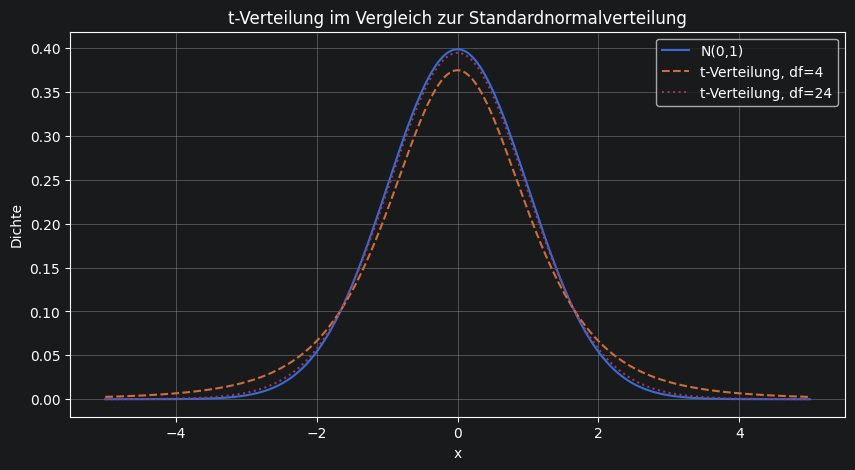

In [39]:
x = np.linspace(-5, 5, 1000)

plt.figure(figsize=(10, 5))
plt.plot(x, stats.norm.pdf(x), label="N(0,1)")
plt.plot(x, stats.t.pdf(x, df=4), linestyle="--", label="t-Verteilung, df=4")
plt.plot(x, stats.t.pdf(x, df=24), linestyle=":", label="t-Verteilung, df=24")
plt.title("t-Verteilung im Vergleich zur Standardnormalverteilung")
plt.xlabel("x")
plt.ylabel("Dichte")
plt.legend()
plt.show()

### Erklärung der Grafik

Die t-Verteilung mit wenigen Freiheitsgraden hat:

- niedrigere Mitte,
- breitere Flanken,
- mehr Wahrscheinlichkeit in den Randbereichen.

Das bedeutet:

> Extreme Werte sind bei der t-Verteilung wahrscheinlicher als bei der Normalverteilung.

Für Konfidenzintervalle heißt das:

- Das t-Quantil ist größer.
- Die Fehlertoleranz wird größer.
- Das Intervall wird breiter.

Je größer \(df\) wird, desto stärker nähert sich die t-Verteilung der Standardnormalverteilung an.

## 9. Quantile: z vs. t

Für 95 % gilt beim z-Intervall:

\[
z_{0{,}975} \approx 1{,}96
\]

Beim t-Intervall hängt das Quantil von den Freiheitsgraden ab.

Die folgende Tabelle zeigt den Unterschied.

In [40]:
dfs = [1, 2, 3, 4, 5, 10, 20, 24, 30, 50, 100, 1000]

print("df    t_0.975")
for df in dfs:
    q = stats.t.ppf(0.975, df)
    print(f"{df:4d}  {q:8.4f}")

print()
print(f"z_0.975 = {stats.norm.ppf(0.975):.4f}")

df    t_0.975
   1   12.7062
   2    4.3027
   3    3.1824
   4    2.7764
   5    2.5706
  10    2.2281
  20    2.0860
  24    2.0639
  30    2.0423
  50    2.0086
 100    1.9840
1000    1.9623

z_0.975 = 1.9600


### Interpretation

Bei kleinen Freiheitsgraden ist das t-Quantil deutlich größer.

Beispiel:

\[
t_{4;0{,}975}=2{,}776
\]

Das ist deutlich größer als:

\[
z_{0{,}975}=1{,}96
\]

Je kleiner die Stichprobe, desto mehr bestraft das t-Intervall die Unsicherheit in der geschätzten Standardabweichung.

## 10. \(\mu\) bei beliebiger Verteilung: großer Stichprobenumfang

Wenn die Grundgesamtheit nicht normalverteilt ist, kann man für den Mittelwert oft trotzdem ein Konfidenzintervall verwenden.

Grundlage ist der **Zentrale Grenzwertsatz**:

\[
\frac{\bar{X}-\mu}{\sigma/\sqrt{n}} \xrightarrow{d} N(0,1)
\]

Das bedeutet:

> Auch wenn die Einzelwerte nicht normalverteilt sind, wird der Mittelwert bei großem \(n\) näherungsweise normalverteilt.

Wichtig:

- Diese Aussage gilt für den Mittelwert.
- Sie setzt unabhängige Beobachtungen und endliche Varianz voraus.
- Die Faustregel \(n \ge 30\) ist nur eine grobe Orientierung.

## 11. Simulation zum Zentralen Grenzwertsatz

Wir starten mit einer stark schiefen Exponentialverteilung.

Dann betrachten wir Mittelwerte aus Stichproben der Größe:

\[
n=1,\quad n=5,\quad n=30,\quad n=100
\]

Je größer \(n\), desto normaler wird die Verteilung der Mittelwerte.

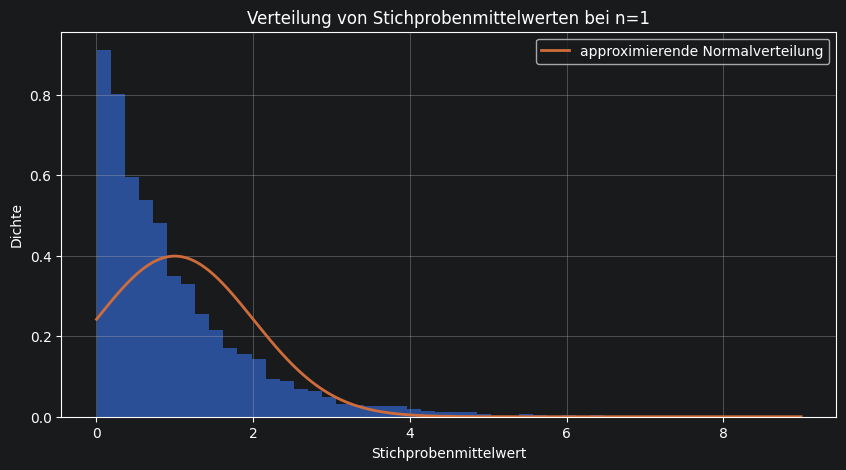

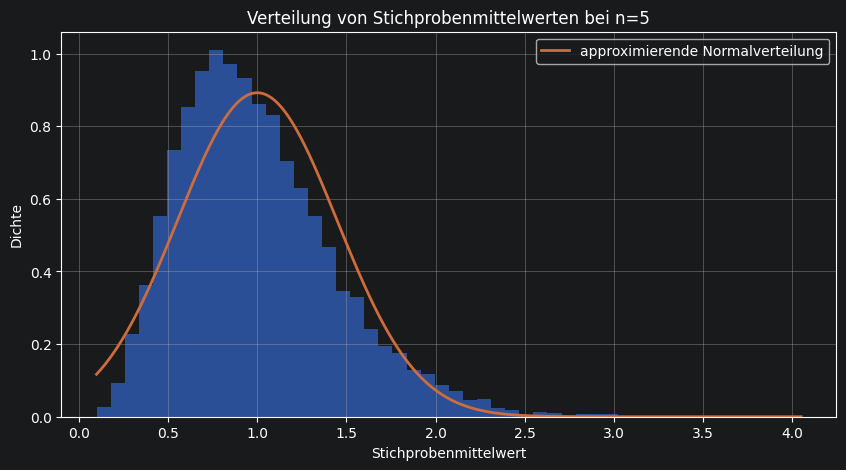

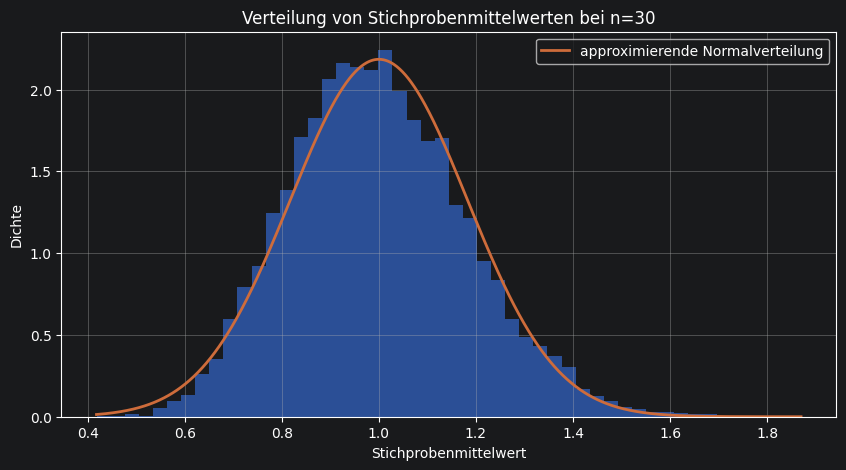

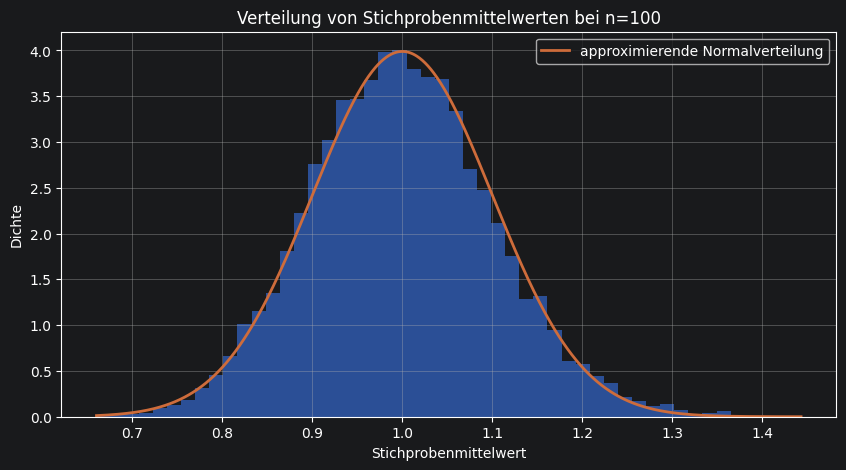

In [41]:
np.random.seed(1)

sample_sizes = [1, 5, 30, 100]
num_simulations = 10000

for n in sample_sizes:
    sample_means = np.mean(np.random.exponential(scale=1.0, size=(num_simulations, n)), axis=1)

    plt.figure(figsize=(10, 5))
    plt.hist(sample_means, bins=50, density=True, alpha=0.65)

    mu = 1.0
    sigma_mean = 1.0 / np.sqrt(n)
    x = np.linspace(sample_means.min(), sample_means.max(), 1000)
    plt.plot(x, stats.norm.pdf(x, loc=mu, scale=sigma_mean), linewidth=2, label="approximierende Normalverteilung")

    plt.title(f"Verteilung von Stichprobenmittelwerten bei n={n}")
    plt.xlabel("Stichprobenmittelwert")
    plt.ylabel("Dichte")
    plt.legend()
    plt.show()

### Erklärung der Grafiken

Bei \(n=1\) sieht man die ursprüngliche Exponentialverteilung: stark rechtsschief.

Bei \(n=5\) wird die Verteilung der Mittelwerte bereits glatter und weniger schief.

Bei \(n=30\) erkennt man deutlich eine Glockenform.

Bei \(n=100\) ist die Verteilung der Mittelwerte sehr nahe an einer Normalverteilung.

Der zentrale Punkt:

> Nicht die Einzelwerte müssen normalverteilt sein.  
> Der Mittelwert wird bei großem \(n\) näherungsweise normalverteilt.

## 12. Konfidenzintervall für einen Anteilswert \(p\)

Viele IT- und Data-Science-Fragen betreffen Anteile:

- Anteil erfolgreicher API-Calls,
- Conversion Rate,
- Anteil fehlerhafter Datensätze,
- Anteil bestandener Tests.

Modell:

\[
X_i \sim Bernoulli(p)
\]

mit:

\[
X_i =
\begin{cases}
1, & \text{Erfolg}\\
0, & \text{Misserfolg}
\end{cases}
\]

Der Schätzer ist:

\[
\hat{p}=\frac{x}{n}
\]

Für große Stichproben gilt näherungsweise:

\[
\hat{p} \approx N\left(p,\frac{p(1-p)}{n}\right)
\]

Da \(p\) unbekannt ist, ersetzt man \(p\) durch \(\hat{p}\):

\[
\widehat{SE}(\hat{p})=
\sqrt{\frac{\hat{p}(1-\hat{p})}{n}}
\]

Das approximative Konfidenzintervall lautet:

\[
\hat{p}\pm z_{1-\alpha/2}
\sqrt{\frac{\hat{p}(1-\hat{p})}{n}}
\]

### Beispiel: Befürworter-Anteil

Gegeben:

- \(n=200\),
- \(x=54\) Erfolge,
- \(\hat{p}=\frac{54}{200}=0{,}27\),
- Konfidenzniveau 95 %.

Faustregel:

\[
n\hat{p}\ge 5
\]

und

\[
n(1-\hat{p})\ge 5
\]

Damit die Normalapproximation vertretbar ist.

In [42]:
n = 200
x_success = 54
p_hat = x_success / n
confidence = 0.95

alpha = 1 - confidence
z = stats.norm.ppf(1 - alpha/2)

se = np.sqrt(p_hat * (1 - p_hat) / n)
margin = z * se
lower = p_hat - margin
upper = p_hat + margin

print("Gegeben:")
print(f"n = {n}")
print(f"x = {x_success}")
print(f"p̂ = x/n = {x_success}/{n} = {de(p_hat, 4)}")
print()
print("Prüfung der Faustregel:")
print(f"n·p̂ = {n} · {de(p_hat, 2)} = {de(n*p_hat, 1)}")
print(f"n·(1-p̂) = {n} · {de(1-p_hat, 2)} = {de(n*(1-p_hat), 1)}")
print()
print("Rechnung:")
print(f"SE = sqrt(p̂(1-p̂)/n) = {de(se, 4)}")
print(f"Fehlertoleranz = {de(z, 3)} · {de(se, 4)} = {de(margin, 4)}")
print()
print("Konfidenzintervall:")
print(f"[{de(lower, 4)}, {de(upper, 4)}]")
print(f"= [{de(100*lower, 1)} %, {de(100*upper, 1)} %]")

Gegeben:
n = 200
x = 54
p̂ = x/n = 54/200 = 0,2700

Prüfung der Faustregel:
n·p̂ = 200 · 0,27 = 54,0
n·(1-p̂) = 200 · 0,73 = 146,0

Rechnung:
SE = sqrt(p̂(1-p̂)/n) = 0,0314
Fehlertoleranz = 1,960 · 0,0314 = 0,0615

Konfidenzintervall:
[0,2085, 0,3315]
= [20,8 %, 33,2 %]


### Erklärung der Rechnung

1. Der beobachtete Anteil ist:

\[
\hat{p}=\frac{54}{200}=0{,}27
\]

2. Der geschätzte Standardfehler ist:

\[
\sqrt{\frac{0{,}27\cdot 0{,}73}{200}}
\approx 0{,}0314
\]

3. Für 95 % wird mit 1,96 multipliziert:

\[
1{,}96\cdot 0{,}0314 \approx 0{,}0615
\]

4. Daraus ergibt sich:

\[
0{,}27 \pm 0{,}0615
\]

also ungefähr:

\[
[0{,}208,\;0{,}332]
\]

In Prozent:

\[
[20{,}8\%,\;33{,}2\%]
\]

## 13. Grafik: Unsicherheit eines Anteils

Der Standardfehler eines Anteils lautet:

\[
\sqrt{\frac{p(1-p)}{n}}
\]

Der Ausdruck \(p(1-p)\) ist bei \(p=0{,}5\) maximal.

Das bedeutet:

> Ein Anteil nahe 50 % ist am unsichersten.  
> Ein Anteil nahe 0 % oder 100 % streut weniger.

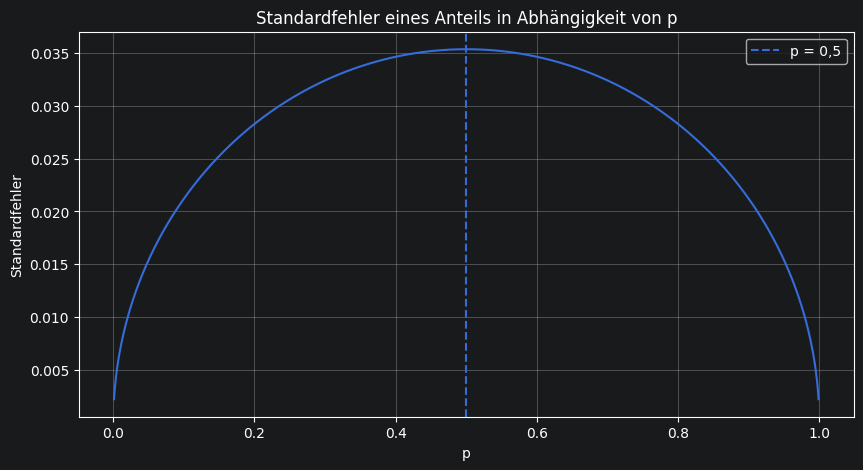

In [43]:
p_values = np.linspace(0.001, 0.999, 1000)
n = 200
se_values = np.sqrt(p_values * (1 - p_values) / n)

plt.figure(figsize=(10, 5))
plt.plot(p_values, se_values)
plt.axvline(0.5, linestyle="--", label="p = 0,5")
plt.title("Standardfehler eines Anteils in Abhängigkeit von p")
plt.xlabel("p")
plt.ylabel("Standardfehler")
plt.legend()
plt.show()

### Erklärung der Grafik

Die Kurve ist symmetrisch um \(p=0{,}5\).

Bei \(p=0{,}5\) ist die Unsicherheit maximal, weil \(p(1-p)\) dort den größten Wert hat:

\[
0{,}5\cdot 0{,}5 = 0{,}25
\]

Deshalb verwendet man bei der Planung eines Stichprobenumfangs oft konservativ \(p=0{,}5\), wenn man den wahren Anteil noch nicht kennt.

## 14. Konfidenzintervall für \(\sigma^2\)

Neben dem Mittelwert kann auch die Streuung selbst interessant sein.

Beispiele:

- Schwankung der API-Response-Zeiten,
- Stabilität von CPU-Temperaturen,
- Varianz täglicher Commit-Zahlen.

Für normalverteilte Daten gilt:

\[
\frac{(n-1)S^2}{\sigma^2}\sim \chi^2_{n-1}
\]

Daraus folgt das Konfidenzintervall:

\[
\left[
\frac{(n-1)s^2}{\chi^2_{n-1;1-\alpha/2}},
\quad
\frac{(n-1)s^2}{\chi^2_{n-1;\alpha/2}}
\right]
\]

Achtung:

> Das größere Chi-Quadrat-Quantil steht im Nenner der unteren Grenze.  
> Das kleinere Chi-Quadrat-Quantil steht im Nenner der oberen Grenze.

### Warum ist das Intervall asymmetrisch?

Die Chi-Quadrat-Verteilung ist nicht symmetrisch.

Sie entsteht als Summe quadrierter Standardnormalvariablen:

\[
\chi^2_k = Z_1^2 + Z_2^2 + \dots + Z_k^2
\]

Da Quadrate nie negativ sind, ist die Verteilung nur für Werte \(\ge 0\) definiert.

Gerade bei kleinen Freiheitsgraden ist sie deutlich rechtsschief.

### Beispiel: CPU-Temperatur

Gegeben:

- \(n=15\),
- \(s^2=25\),
- Konfidenzniveau 95 %.

Freiheitsgrade:

\[
df=n-1=14
\]

Benötigte Quantile:

\[
\chi^2_{14;0{,}025}
\quad \text{und} \quad
\chi^2_{14;0{,}975}
\]

In [44]:
n = 15
s2 = 25
confidence = 0.95

alpha = 1 - confidence
df = n - 1

chi2_lower_quantile = stats.chi2.ppf(alpha/2, df)
chi2_upper_quantile = stats.chi2.ppf(1 - alpha/2, df)

lower_var = (n - 1) * s2 / chi2_upper_quantile
upper_var = (n - 1) * s2 / chi2_lower_quantile

lower_sd = np.sqrt(lower_var)
upper_sd = np.sqrt(upper_var)

print("Gegeben:")
print(f"n = {n}")
print(f"s² = {s2}")
print(f"df = {df}")
print()
print("Chi-Quadrat-Quantile:")
print(f"χ²_({df}; {de(alpha/2, 3)}) = {de(chi2_lower_quantile, 3)}")
print(f"χ²_({df}; {de(1-alpha/2, 3)}) = {de(chi2_upper_quantile, 3)}")
print()
print("Konfidenzintervall für σ²:")
print(f"untere Grenze = (n-1)s² / χ²_oben = {df} · {s2} / {de(chi2_upper_quantile, 3)} = {de(lower_var, 2)}")
print(f"obere Grenze = (n-1)s² / χ²_unten = {df} · {s2} / {de(chi2_lower_quantile, 3)} = {de(upper_var, 2)}")
print(f"KI für σ² = [{de(lower_var, 2)}, {de(upper_var, 2)}]")
print()
print("Konfidenzintervall für σ:")
print(f"KI für σ = [{de(lower_sd, 2)}, {de(upper_sd, 2)}]")

Gegeben:
n = 15
s² = 25
df = 14

Chi-Quadrat-Quantile:
χ²_(14; 0,025) = 5,629
χ²_(14; 0,975) = 26,119

Konfidenzintervall für σ²:
untere Grenze = (n-1)s² / χ²_oben = 14 · 25 / 26,119 = 13,40
obere Grenze = (n-1)s² / χ²_unten = 14 · 25 / 5,629 = 62,18
KI für σ² = [13,40, 62,18]

Konfidenzintervall für σ:
KI für σ = [3,66, 7,89]


### Erklärung der Rechnung

Die Formel lautet:

\[
\left[
\frac{(n-1)s^2}{\chi^2_{n-1;1-\alpha/2}},
\quad
\frac{(n-1)s^2}{\chi^2_{n-1;\alpha/2}}
\right]
\]

Mit \(n=15\) und \(s^2=25\) ist:

\[
(n-1)s^2 = 14\cdot 25 = 350
\]

Für 95 % gilt:

\[
\alpha/2=0{,}025
\]

und

\[
1-\alpha/2=0{,}975
\]

Daher:

\[
\text{untere Grenze}
=
\frac{350}{\chi^2_{14;0{,}975}}
\]

\[
\text{obere Grenze}
=
\frac{350}{\chi^2_{14;0{,}025}}
\]

Da \(\chi^2_{14;0{,}025}\) viel kleiner ist, wird die obere Grenze deutlich größer.

Das erklärt die Asymmetrie.

## 15. Grafik: Chi-Quadrat-Verteilung und Quantile

Die folgende Grafik zeigt die beiden Quantile für \(df=14\) bei einem 95 %-Intervall.

Links liegen 2,5 % der Fläche, rechts ebenfalls 2,5 %.  
Der mittlere Bereich enthält 95 %.


### Wichtige Ergänzung: gleiche Randflächen, aber unterschiedliche Abstände

Beim zweiseitigen Konfidenzintervall werden bei der Chi-Quadrat-Verteilung links und rechts jeweils gleich viel **Fläche** abgeschnitten:

\[
P\left(X \le \chi^2_{df;\alpha/2}\right)=\frac{\alpha}{2}
\]

und

\[
P\left(X \ge \chi^2_{df;1-\alpha/2}\right)=\frac{\alpha}{2}.
\]

Für ein 95-%-Intervall gilt also:

\[
\alpha = 0{,}05
\]

und damit:

\[
\frac{\alpha}{2}=0{,}025.
\]

Das bedeutet:

- links vom unteren Quantil liegen 2,5 % der Fläche,
- rechts vom oberen Quantil liegen ebenfalls 2,5 % der Fläche,
- dazwischen liegen 95 % der Fläche.

Der entscheidende Punkt ist:

> Die **Flächen links und rechts sind gleich groß**, aber die **Abstände auf der x-Achse sind nicht gleich groß**.

Warum?

Die Chi-Quadrat-Verteilung ist **rechtsschief**. Deshalb liegt das rechte Quantil meist deutlich weiter vom Zentrum entfernt als das linke Quantil.

Das erklärt, warum das Konfidenzintervall für \(\sigma^2\) asymmetrisch ist.


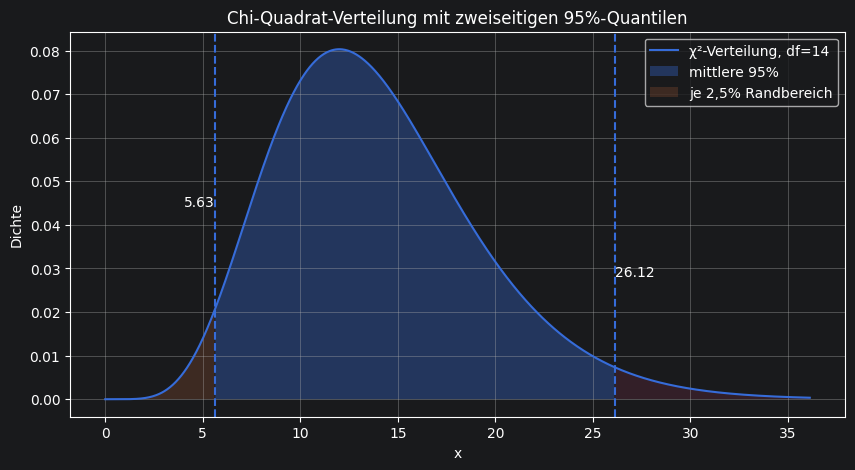

In [45]:
df = 14
alpha = 0.05

q_low = stats.chi2.ppf(alpha/2, df)
q_high = stats.chi2.ppf(1 - alpha/2, df)

x = np.linspace(0, stats.chi2.ppf(0.999, df), 1000)
y = stats.chi2.pdf(x, df)

plt.figure(figsize=(10, 5))
plt.plot(x, y, label=f"χ²-Verteilung, df={df}")
plt.fill_between(x, y, where=(x >= q_low) & (x <= q_high), alpha=0.35, label="mittlere 95%")
plt.fill_between(x, y, where=(x < q_low), alpha=0.2, label="je 2,5% Randbereich")
plt.fill_between(x, y, where=(x > q_high), alpha=0.2)

plt.axvline(q_low, linestyle="--")
plt.axvline(q_high, linestyle="--")
plt.text(q_low, max(y)*0.55, f"{q_low:.2f}", ha="right")
plt.text(q_high, max(y)*0.35, f"{q_high:.2f}", ha="left")

plt.title("Chi-Quadrat-Verteilung mit zweiseitigen 95%-Quantilen")
plt.xlabel("x")
plt.ylabel("Dichte")
plt.legend()
plt.show()

### Erklärung der Grafik

Die Chi-Quadrat-Verteilung ist rechtsschief.

Deshalb liegen die beiden Quantile nicht symmetrisch um den Erwartungswert.

Das ist der zentrale Unterschied zur Normal- und t-Verteilung:

- Normal- und t-Verteilung: symmetrische Intervalle um den Schätzer.
- Chi-Quadrat-Verteilung: asymmetrisches Intervall für \(\sigma^2\).

Für \(\sigma\) zieht man anschließend aus beiden Grenzen die Wurzel.

## 16. Entscheidungslogik: Welches Intervall?

Die wichtigsten Fälle:

| Zielparameter | Situation | Intervall |
|---|---|---|
| \(\mu\) | normalverteilt, \(\sigma\) bekannt | z-Intervall |
| \(\mu\) | normalverteilt, \(\sigma\) unbekannt | t-Intervall |
| \(\mu\) | beliebige Verteilung, großes \(n\) | approximatives z- oder t-Intervall |
| \(p\) | Anteil / Bernoulli, großes \(n\) | approximatives Anteilsintervall |
| \(\sigma^2\) | normalverteilte Daten | Chi-Quadrat-Intervall |

Die wichtigste praktische Frage lautet:

> Was soll geschätzt werden: Mittelwert, Anteil oder Varianz?

## 17. Zusammenhang: Intervallbreite und Stichprobenumfang

Für ein z-Intervall gilt:

\[
E = z_{1-\alpha/2}\frac{\sigma}{\sqrt{n}}
\]

Wenn eine maximale Fehlertoleranz \(E\) vorgegeben ist, kann man nach \(n\) auflösen:

\[
n =
\left(
\frac{z_{1-\alpha/2}\sigma}{E}
\right)^2
\]

Diese Formel zeigt:

- kleinere Fehlertoleranz → größeres \(n\),
- größere Streuung → größeres \(n\),
- höheres Konfidenzniveau → größeres \(n\).

In [46]:
sigma = 30
confidence = 0.95
alpha = 1 - confidence
z = stats.norm.ppf(1 - alpha/2)

desired_errors = [10, 7.5, 5, 3, 2]

print("Benötigter Stichprobenumfang für verschiedene Fehlertoleranzen")
print(f"σ = {sigma}, Konfidenzniveau = {confidence:.0%}")
print()

for E in desired_errors:
    n_required = (z * sigma / E) ** 2
    print(f"E = {E:4.1f} ms -> n >= {np.ceil(n_required):.0f}")

Benötigter Stichprobenumfang für verschiedene Fehlertoleranzen
σ = 30, Konfidenzniveau = 95%

E = 10.0 ms -> n >= 35
E =  7.5 ms -> n >= 62
E =  5.0 ms -> n >= 139
E =  3.0 ms -> n >= 385
E =  2.0 ms -> n >= 865


### Erklärung

Die Formel enthält ein Quadrat.

Deshalb steigen die benötigten Stichprobenumfänge schnell an.

Wenn die gewünschte Fehlertoleranz halbiert wird, vervierfacht sich ungefähr der Stichprobenumfang.

## 18. Zusammenfassung

### Zentrale Begriffe

- **Punktschätzer:** ein einzelner Schätzwert, z.B. \(\bar{x}\).
- **Konfidenzintervall:** Bereich plausibler Werte für den unbekannten Parameter.
- **Konfidenzniveau:** langfristige Überdeckungswahrscheinlichkeit des Verfahrens.
- **Standardfehler:** Streuung des Schätzers.
- **Quantil:** Sicherheitsfaktor der passenden Verteilung.

### Zentrale Formeln

Mittelwert, \(\sigma\) bekannt:

\[
\bar{x} \pm z_{1-\alpha/2}\frac{\sigma}{\sqrt{n}}
\]

Mittelwert, \(\sigma\) unbekannt:

\[
\bar{x} \pm t_{n-1;1-\alpha/2}\frac{s}{\sqrt{n}}
\]

Anteilswert:

\[
\hat{p}\pm z_{1-\alpha/2}
\sqrt{\frac{\hat{p}(1-\hat{p})}{n}}
\]

Varianz:

\[
\left[
\frac{(n-1)s^2}{\chi^2_{n-1;1-\alpha/2}},
\quad
\frac{(n-1)s^2}{\chi^2_{n-1;\alpha/2}}
\right]
\]

### Wichtigster Merksatz

> Ein 95 %-Konfidenzintervall bedeutet nicht, dass der Parameter mit 95 % Wahrscheinlichkeit in genau diesem Intervall liegt.  
> Es bedeutet, dass das Verfahren bei häufiger Wiederholung in etwa 95 % der Fälle ein Intervall erzeugt, das den wahren Parameter überdeckt.

## 19. Spickzettel

1. **Mittelwert und \(\sigma\) bekannt:** z-Intervall.  
2. **Mittelwert und \(\sigma\) unbekannt:** t-Intervall.  
3. **Anteil:** Normalapproximation nur, wenn genügend Erfolge und Misserfolge vorliegen.  
4. **Varianz:** Chi-Quadrat-Intervall, asymmetrisch.  
5. **Größeres \(n\):** Intervall wird enger.  
6. **Höheres Konfidenzniveau:** Intervall wird breiter.  
7. **Kleine Stichprobe:** t statt z verwenden, wenn \(\sigma\) unbekannt ist.